Accuracy: 1.0
              precision    recall  f1-score   support

       Alert       1.00      1.00      1.00         5
      Drowsy       1.00      1.00      1.00         5

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10

Prediction: Drowsy


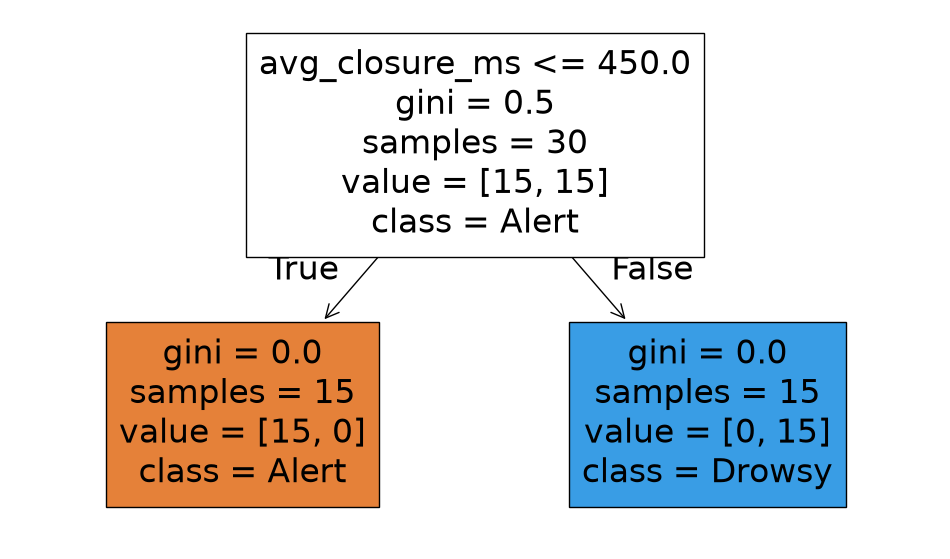

In [1]:
#Write a program using a Decision Tree classifier to predict whether a driver is Alert or Drowsy based on eye closure data. 
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# CSV columns:
# closure_ratio, avg_closure_ms, blink_rate, label
data = pd.read_csv("eye_closure.csv")

X = data[["closure_ratio", "avg_closure_ms", "blink_rate"]]
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=3,
    random_state=42
)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

# Test one new driver observation
new_driver = pd.DataFrame(
    [[0.48, 850, 4]],
    columns=X.columns

)
print("Prediction:", model.predict(new_driver)[0])

plt.figure(figsize=(12,7))
plot_tree(model, feature_names=X.columns,
          class_names=model.classes_, filled=True)
plt.show()

